In [51]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/all_reviews_dataset.csv")
df.head()

,business_id,business_name,city,state,categories,review_id,clean_text,date,review_stars,review_length
0,XQfwVwDr-v0ZS3_CbbE5Xw,Turning Point of North Wales,North Wales,PA,"Restaurants, Breakfast & Brunch, Food, Juice B...",KU_O5udG6zpxOg-VcAEodg,if you decide to eat here just be aware it is ...,2018-07-07 22:09:11,3,101
1,7ATYjTIgM3jUlt4UM3IypQ,Body Cycle Spinning Studio,Philadelphia,PA,"Active Life, Cycling Classes, Trainers, Gyms, ...",BiTunyQ73aT9WBnpR9DZGw,ive taken a lot of spin classes over the years...,2012-01-03 15:28:18,5,151
2,YjUWPpI6HXG530lwP-fb2A,Kettle Restaurant,Tucson,AZ,"Restaurants, Breakfast & Brunch",saUsX_uimxRlCVr67Z4Jig,family diner had the buffet eclectic assortmen...,2014-02-05 20:30:30,3,55
3,kxX2SOes4o-D3ZQBkiMRfA,Zaika,Philadelphia,PA,"Halal, Pakistani, Restaurants, Indian",AqPFMleE6RsU23_auESxiA,wow yummy different delicious our favorite is ...,2015-01-04 00:01:03,5,40
4,e4Vwtrqf-wpJfwesgvdgxQ,Melt,New Orleans,LA,"Sandwiches, Beer, Wine & Spirits, Bars, Food, ...",Sx8TMOWLNuJBWer-0pcmoA,cute interior and owner gave us tour of upcomi...,2017-01-14 20:54:15,4,93


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71587 entries, 0 to 71586
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   business_id    71587 non-null  str  
 1   business_name  71587 non-null  str  
 2   city           71587 non-null  str  
 3   state          71587 non-null  str  
 4   categories     71587 non-null  str  
 5   review_id      71587 non-null  str  
 6   clean_text     71587 non-null  str  
 7   date           71587 non-null  str  
 8   review_stars   71587 non-null  int64
 9   review_length  71587 non-null  int64
dtypes: int64(2), str(8)
memory usage: 5.5 MB


In [29]:
cities = df["city"].unique()
# "Boston" in cities
"Las Vegas" in cities

False

In [10]:
# 95th [percentile]
review_length_95th = np.percentile(df["review_length"], 95)
review_length_75th = np.percentile(df["review_length"], 75)
review_length_50th = np.percentile(df["review_length"], 50)

review_length_95th, review_length_75th, review_length_50th

(np.float64(289.0), np.float64(137.0), np.float64(81.0))

In [25]:
#breakfast spots in Alton
filter_1 = (df["city"] == "Alton") & (df["categories"].str.contains("Breakfast", case = False))
alton_breakfast_reviews = df[filter_1]
ground_truth_labels = set(alton_breakfast_reviews["review_id"].tolist())
ground_truth_labels

{'lkqx0KRpwch6oH2N91-BCw', 'pIGUls8vJpPMd5iviM-5ng', 'sC1npSy8THMlpspwuQdauA'}

In [26]:
df.state.value_counts()

state
PA    18579
FL     9939
LA     9388
TN     6466
MO     5549
IN     4762
NV     3887
AZ     3756
CA     3536
NJ     2441
AB     1311
ID      950
DE      545
IL      469
CO        6
NC        2
HI        1
Name: count, dtype: int64

In [28]:
df.city.value_counts()[:50]

city
Philadelphia        12438
New Orleans          8150
Nashville            4806
Tampa                3923
Indianapolis         3636
Tucson               3572
Saint Louis          3410
Reno                 3378
Santa Barbara        2630
Edmonton             1210
Saint Petersburg      723
Franklin              703
Boise                 680
Clearwater            642
Metairie              572
St. Petersburg        532
Cherry Hill           502
Sparks                490
Goleta                476
Carmel                422
Wilmington            376
St. Louis             358
Kenner                326
Brandon               319
Carpinteria           296
West Chester          294
St Petersburg         293
St Louis              291
Brentwood             290
Clearwater Beach      289
Media                 257
Fishers               246
Exton                 237
Ardmore               231
Pinellas Park         215
Springfield           207
Clayton               204
Tarpon Springs        199
Wayne  

In [53]:
# pet groomers
df_pet = df[df["categories"].str.contains("sushi", case = False)]
df_pet

,business_id,business_name,city,state,categories,review_id,clean_text,date,review_stars,review_length
9,gebiRewfieSdtt17PTW6Zg,Hibachi Steak House & Sushi Bar,Santa Barbara,CA,"Steakhouses, Sushi Bars, Restaurants, Japanese",pUycOfUwM8vqX7KjRRhUEA,had a party of 6 here for hibachi our waitress...,2016-07-25 07:31:06,3,97
21,vC2qm1y3Au5czBtbhc-DNw,Sushi Teri,Carpinteria,CA,"Restaurants, Sushi Bars",eCiWBf1CJ0Zdv1uVarEhhw,yes this is the only sushi place in town howev...,2013-09-04 03:48:20,4,58
22,cPepkJeRMtHapc_b2Oe_dw,Naked Tchopstix Express,Indianapolis,IN,"Restaurants, Food, Poke, Hawaiian, Sushi Bars",lUUhg8ltDsUZ9h0xnwY4Dg,i was really between 3 and 4 stars for this on...,2018-07-17 03:30:07,4,311
64,5Ce3lZksYVkCbrihqylVHQ,Sushi Nara,Tucson,AZ,"Sushi Bars, Japanese, Restaurants",ymhbOMW63B_vGaRFR3XT0A,i just started going to sushi nara this month ...,2014-07-25 17:56:26,5,95
117,ab3pRv-b0o-BwMK2jVbH3Q,Saki Endless Sushi & Hibachi Eatery,Clearwater,FL,"Restaurants, Salad, Sushi Bars, Soup, Japanese",RMho6HMpdec1YgIypwWQrQ,my husband and i come here often we love the f...,2018-08-24 00:52:13,5,31
...,...,...,...,...,...,...,...,...,...,...
71312,TUhRukcZb3tG0cB_X68FCQ,Noboru,North Wales,PA,"Restaurants, Buffets, Food, Do-It-Yourself Foo...",-cL_eVl3TduRTMjgYHe38g,ive been here quite a few times nothing impres...,2014-02-12 00:05:43,4,64
71348,_EKvNMC2Mm67HzqNIzLgXg,Temaki Sushi,Media,PA,"Restaurants, Sushi Bars, Japanese",yy4N9OfZk7aO8bkPk42LlA,service was excellent from manager owner melin...,2012-07-01 13:28:15,3,149
71365,71U7MxQEhwitJOm4CQpRwQ,KELP Sushi Joint,Tampa,FL,"Japanese, Sushi Bars, Food, Restaurants, Asian...",vJwjD5nl06paeU2sZkiRYA,fresh and affordable sushi i found the lobster...,2017-07-21 00:59:01,4,30
71485,q39t6-a47CLf1RTyqu9CYg,Sake Cafe of Elmwood,New Orleans,LA,"Japanese, Restaurants, Sushi Bars",iypMdGEt2EOmhQlLYOoH8A,they have a sushi happy hour which is cool we ...,2013-07-16 15:59:03,3,30


In [48]:
import pickle

with open("data/ground_truth_labels.pkl", "rb") as f:
    ground_truths = pickle.load(f)
ground_truths, len(ground_truths    )

([{'query': 'breakfast spots in Alton',
   'metadata_filter': {'city': 'Alton', 'categories': 'Breakfast'},
   'review_ids': {'lkqx0KRpwch6oH2N91-BCw',
    'pIGUls8vJpPMd5iviM-5ng',
    'sC1npSy8THMlpspwuQdauA'}},
  {'query': 'reviews of Kettle Restaurant',
   'metadata_filter': {'business_name': 'Kettle Restaurant'},
   'review_ids': {'7pn3auavTDZyDKlAAku1Og',
    '8Jl2ezWRPtg0ElypIqATDQ',
    'E21dO10aI0pXCuoDNeSY6A',
    'Izs72sMY0cCXtHs5exObZw',
    'K2NBIqVgL5QrkENzt41mCQ',
    'lD6VsDRCu9aTUr1NMC2xFg',
    'oUrKJzj_qZybqqPatE9q1A',
    'pp6xwk2MBoNlM8y6e5EhPg',
    'saUsX_uimxRlCVr67Z4Jig',
    'zS89yli1LPr6ZCXSLr4ocw'}},
  {'query': 'brunch spots in Clearwater',
   'metadata_filter': {'city': 'Clearwater', 'categories': 'Brunch'},
   'review_ids': {'-Lkjo_vV2DEemMpMBlbeHA',
    '-zJEgE-_MdBjzb0v9OgJzA',
    '0Jx3YfSHTJHpINR6q3io3A',
    '0NX8k_N1kouOXSLVLh8Knw',
    '0QYPffjuvgDziEtxj79PTA',
    '0yujhknSN1JgmdfcuSK4Yg',
    '1zITZH87MsQld4zSM9eOzg',
    '2IX8KNPeFDVByGT8cfMIkw'

In [49]:
results = pd.read_csv("data/retrieval_evaluation_results.csv")
results

,embedding_model,chunk_size,use_metadata_filter,avg_precision,avg_recall,avg_f1_score
0,sentence-transformers/all-MiniLM-L6-v2,800,True,0.980703,1.000000,0.988624
1,sentence-transformers/all-MiniLM-L6-v2,800,False,0.072501,0.135848,0.094412
2,sentence-transformers/all-MiniLM-L6-v2,289,True,0.978619,0.794523,0.869588
3,sentence-transformers/all-MiniLM-L6-v2,289,False,0.075448,0.129217,0.094690
4,sentence-transformers/all-MiniLM-L6-v2,137,True,0.974337,0.388402,0.549083
5,sentence-transformers/all-MiniLM-L6-v2,137,False,0.075273,0.129804,0.094772
6,sentence-transformers/all-MiniLM-L6-v2,81,True,0.974552,0.268059,0.409500
7,sentence-transformers/all-MiniLM-L6-v2,81,False,0.070285,0.119816,0.088429
8,sentence-transformers/all-mpnet-base-v2,800,True,0.980703,1.000000,0.988624
9,sentence-transformers/all-mpnet-base-v2,800,False,0.105577,0.201937,0.138501


In [50]:
print('results shape:', results.shape)
print('columns:', results.columns.tolist())
for col in ['embedding_model','chunk_size','use_metadata_filter']:
    if col in results.columns:
        vals = sorted(results[col].dropna().unique().tolist())
        print(f"{col} unique ({len(vals)}):", vals)

numeric_cols = results.select_dtypes(include='number').columns.tolist()
print('numeric columns:', numeric_cols)

results shape: (32, 6)
columns: ['embedding_model', 'chunk_size', 'use_metadata_filter', 'avg_precision', 'avg_recall', 'avg_f1_score']
embedding_model unique (4): ['BAAI/bge-base-en-v1.5', 'BAAI/bge-small-en-v1.5', 'sentence-transformers/all-MiniLM-L6-v2', 'sentence-transformers/all-mpnet-base-v2']
chunk_size unique (4): [81, 137, 289, 800]
use_metadata_filter unique (2): [False, True]
numeric columns: ['chunk_size', 'avg_precision', 'avg_recall', 'avg_f1_score']


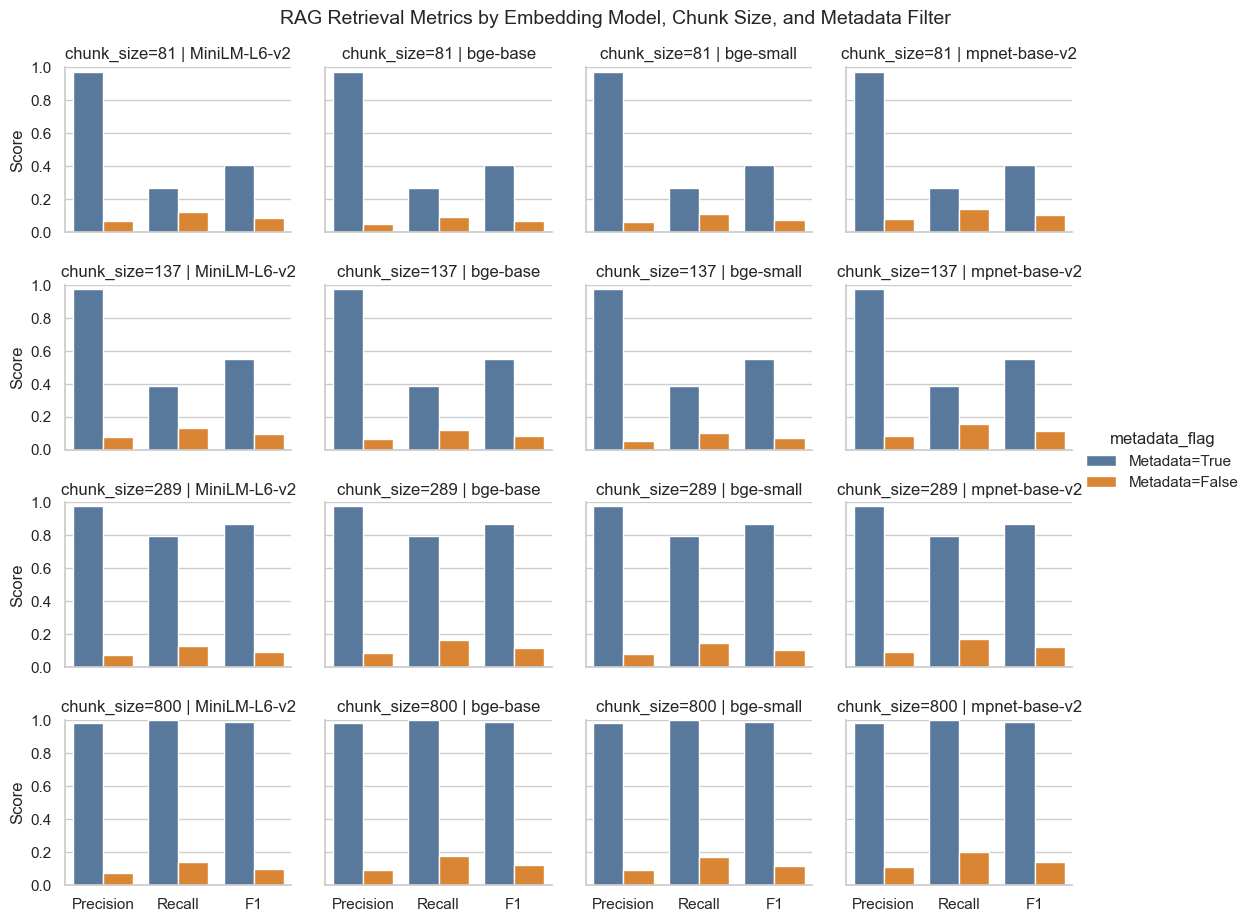

In [52]:
# Use your in-memory results dataframe
plot_df = results.copy()

# Make labels cleaner
model_short = {
    "BAAI/bge-base-en-v1.5": "bge-base",
    "BAAI/bge-small-en-v1.5": "bge-small",
    "sentence-transformers/all-MiniLM-L6-v2": "MiniLM-L6-v2",
    "sentence-transformers/all-mpnet-base-v2": "mpnet-base-v2",
}
plot_df["embedding_model_short"] = plot_df["embedding_model"].map(model_short).fillna(plot_df["embedding_model"])
plot_df["metadata_flag"] = plot_df["use_metadata_filter"].map({True: "Metadata=True", False: "Metadata=False"})

# Long format for grouped bars
long_df = plot_df.melt(
    id_vars=["embedding_model_short", "chunk_size", "metadata_flag"],
    value_vars=["avg_precision", "avg_recall", "avg_f1_score"],
    var_name="metric",
    value_name="score"
)

metric_labels = {
    "avg_precision": "Precision",
    "avg_recall": "Recall",
    "avg_f1_score": "F1"
}
long_df["metric"] = long_df["metric"].map(metric_labels)

# Keep deterministic ordering
row_order = sorted(long_df["chunk_size"].unique().tolist())
col_order = sorted(long_df["embedding_model_short"].unique().tolist())

sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=long_df,
    kind="bar",
    x="metric",
    y="score",
    hue="metadata_flag",
    row="chunk_size",
    col="embedding_model_short",
    row_order=row_order,
    col_order=col_order,
    height=2.4,
    aspect=1.15,
    palette=["#4C78A8", "#F58518"],
    legend=True,
    sharey=True
)

g.set_axis_labels("", "Score")
g.set_titles(row_template="chunk_size={row_name}", col_template="{col_name}")

# Make bars easier to read
for ax in g.axes.flat:
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=0)

g.fig.subplots_adjust(top=0.92, hspace=0.32, wspace=0.15)
g.fig.suptitle("RAG Retrieval Metrics by Embedding Model, Chunk Size, and Metadata Filter", fontsize=14)

plt.show()